In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier')
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2_IBQ')


from Tokenizer.OpenMAGViT2 import OpenMAGViT2
from Tiler import Tiler
from utils import load_all_images

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

In [4]:
processing_ratio = 1.0 # 0.9, 0.8, 0.7
tile_resize = 256
batch_size = 8

In [5]:
tokenizer = OpenMAGViT2(
    config_file="/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2_IBQ/configs/Open-MAGVIT2/gpu/imagenet_lfqgan_128_L.yaml",
    ckpt_path="/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/OpenMAGViT2_IBQ/upload_ckpts/Open-MAGVIT2/imagenet_128_L.ckpt",
)

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from src/Open_MAGVIT2/modules/autoencoder/lpips/vgg.pth
Use the Discriminator without Bluring
VQLPIPSWithDiscriminator running with hinge loss.
OpenMAGViT2 model loaded successfully
Missing keys: ['loss.perceptual_loss.scaling_layer.shift', 'loss.perceptual_loss.scaling_layer.scale', 'loss.perceptual_loss.net.slice1.0.weight', 'loss.perceptual_loss.net.slice1.0.bias', 'loss.perceptual_loss.net.slice1.2.weight', 'loss.perceptual_loss.net.slice1.2.bias', 'loss.perceptual_loss.net.slice2.5.weight', 'loss.perceptual_loss.net.slice2.5.bias', 'loss.perceptual_loss.net.slice2.7.weight', 'loss.perceptual_loss.net.slice2.7.bias', 'loss.perceptual_loss.net.slice3.10.weight', 'loss.perceptual_loss.net.slice3.10.bias', 'loss.perceptual_loss.net.slice3.12.weight', 'loss.perceptual_loss.net.slice3.12.bias', 'loss.perceptual_loss.net.slice3.14.weight', 'loss.perceptual_loss.net.slice3.14.bias', 'loss.perceptual_loss.net.slice4.17.weight', 'loss.perceptual_loss.net.slice4.

In [6]:
tiler = Tiler(tile_size=256, pad_value=-1.0)

Linear scaling ratio: 256/256 = 1.000
Pixel per tile ratio: 256²/256² = 1.000
No pixel change: same resolution processing


In [7]:
# Load image paths
folder_path = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original'
images, image_names, image_paths = load_all_images(folder_path)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: mri_human_brain.png
Loaded: physics1.png
Loaded: physics2.png
Loaded: tcp_1.png


Original image: 3×270×527
Downsampling to: 270×527 (ratio: 1.000)
Padding to: 512×768
Creating 2×3 = 6 tiles of 256×256
Showing 2×3 = 6 tiles


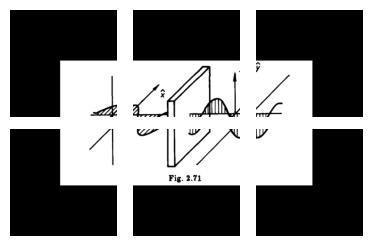

In [8]:
image = images[7]
res = tiler(images[7])
tiler.show_tiles(res['tiles'], res['metadata'])

In [9]:
image_tensor = tokenizer.preprocess(image).squeeze(0)
image_tiled = tiler(image_tensor)['tiles'].to('cuda')

Original image: 3×270×527
Downsampling to: 270×527 (ratio: 1.000)
Padding to: 512×768
Creating 2×3 = 6 tiles of 256×256


In [13]:
with tokenizer.model.ema_scope():
    quant, diff, indices, _ = tokenizer.model.encode(image_tiled)

In [22]:
indices

tensor([205411,  82491, 208674,  ..., 199186, 207435, 197138], device='cuda:0')

In [29]:
# Add missing method to your LFQ model
def indices_to_codes(self, indices):
   bits = self.indices_to_bits(indices)
   return bits.float() * 2.0 - 1.0

import types
tokenizer.model.quantize.indices_to_codes = types.MethodType(indices_to_codes, tokenizer.model.quantize)

# Now decode your index
shaped_indices = torch.tensor([[[[207435, 197138]]]]).long().to(tokenizer.device)
quant_codes = tokenizer.model.quantize.indices_to_codes(shaped_indices)

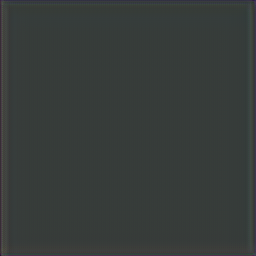

In [45]:
# Create full spatial grid with your index
full_indices = torch.full((1, 32, 32), 197138).long().to(tokenizer.device)

# Convert to quantized codes
quant_codes = tokenizer.model.quantize.indices_to_codes(full_indices)  # [1, 32, 32, 18]
quant_codes = quant_codes.permute(0, 3, 1, 2)  # [1, 18, 32, 32] - correct format

# Decode to full image
with torch.no_grad():
    reconstructed = tokenizer.model.decode(quant_codes)

# Convert to PIL image
reconstructed_image = tokenizer.postprocess(reconstructed.detach())
reconstructed_image.show()

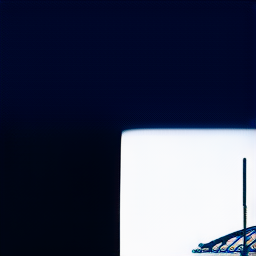

In [48]:
# Get original quant (assuming you have it from earlier)
# quant.shape is [6, 18, 32, 32]

# Take the first tile
first_tile_quant = quant[0:1]  # [1, 18, 32, 32]

token_id = 82491
half_height = 32 // 2  # 16

# Create indices for first half (top half)
replacement_indices = torch.full((1, half_height, 32), token_id).long().to(tokenizer.device)

# Convert your indices to quant codes
replacement_quant = tokenizer.model.quantize.indices_to_codes(replacement_indices)  # [1, 16, 32, 18]
replacement_quant = replacement_quant.permute(0, 3, 1, 2)  # [1, 18, 16, 32]

# Replace first half of the tile
modified_quant = first_tile_quant.clone()
modified_quant[:, :, :half_height, :] = replacement_quant

# Decode the modified tile
with torch.no_grad():
   reconstructed = tokenizer.model.decode(modified_quant)

# Convert to PIL image
reconstructed_image = tokenizer.postprocess(reconstructed.detach())
reconstructed_image.show()

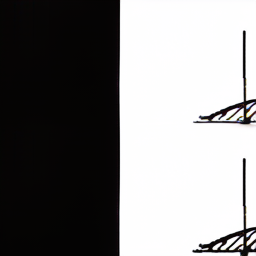

In [43]:
# Clone first_tile_quant to avoid modifying original
modified_quant = first_tile_quant.clone()

# Duplicate second half to first half
half_height = 32 // 2  # 16
modified_quant[:, :, :half_height, :] = modified_quant[:, :, half_height:, :]  # Copy bottom half to top half

# Decode to full image
with torch.no_grad():
   reconstructed = tokenizer.model.decode(modified_quant)

# Convert to PIL image
reconstructed_image = tokenizer.postprocess(reconstructed.detach())
reconstructed_image.show()

In [44]:
# Test if it's spatial context
uniform_quant = first_tile_quant[:, :, 0:1, 0:1].expand(-1, -1, 32, 32)
with torch.no_grad():
    uniform_recon = tokenizer.model.decode(uniform_quant)

# Check if even uniform input produces non-uniform output
center = uniform_recon[:, :, 16, 16].mean()
corner = uniform_recon[:, :, 0, 0].mean()
print(f"Center vs corner difference: {(center - corner).abs().item()}")

Center vs corner difference: 0.018615812063217163


In [ ]:


# Initialize tiler
tile_orig_size = 360
tile_resize = 256
tiler = Tiler(tile_size=tile_orig_size, pad_value=-1.0, tile_resize=tile_resize)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Setup paths
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{tokenizer.name}_{tile_orig_size}-{tile_resize}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

# Reduce batch size to avoid memory issues
batch_size = 8

# Load image paths
folder_path = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original'
images, image_names, image_paths = load_all_images(folder_path)

print(f"Found {len(images)} images to process")
print(f"Using tiler with tile_size={tiler.tile_size}")
print(f"Processing tiles in batches of {batch_size}")

# Process each image with tiling
with torch.no_grad():
    for idx, (image, name) in enumerate(zip(images, image_names)):
        print(f"\n{'='*60}")
        print(f"Processing image {idx+1}/{len(images)}: {name}")
        print(f"{'='*60}")

        # Use tokenizer's preprocess method but remove batch dimension for tiling
        image_tensor = tokenizer.preprocess(image).squeeze(0)
        print(f"Normalized image shape: {image_tensor.shape}")

        # Tile the normalized image
        print("🔲 Tiling image...")
        result = tiler(image_tensor)
        tiles = result['tiles']  # Shape: (total_tiles, C, tile_h, tile_w)
        metadata = result['metadata']

        print(f"Number of tiles: {tiles.shape[0]}")
        print(f"Tile shape: {tiles.shape[1:]}")

        # Process tiles in batches to avoid OOM
        total_tiles = tiles.shape[0]
        reconstructed_tiles_list = []
        all_indices = []

        print(f"🔄 Processing {total_tiles} tiles in batches of {batch_size}")

        for i in range(0, total_tiles, batch_size):
            end_idx = min(i + batch_size, total_tiles)
            batch_tiles = tiles[i:end_idx].to(device)

            print(f"  📦 Processing batch {i//batch_size + 1}/{(total_tiles + batch_size - 1)//batch_size}: tiles {i+1}-{end_idx}")

            # Process this batch through the tokenizer
            indices, additional_info = tokenizer.encode(batch_tiles)
            reconstructed_batch = tokenizer.decode(indices, additional_info)

            # Clamp and move to CPU to save GPU memory
            reconstructed_batch = reconstructed_batch.clamp(-1, 1).cpu()
            reconstructed_tiles_list.append(reconstructed_batch)
            all_indices.append(indices.cpu())

            # Clear GPU memory
            del batch_tiles, reconstructed_batch, indices
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Concatenate all results
        reconstructed_tiles = torch.cat(reconstructed_tiles_list, dim=0)
        all_indices_tensor = torch.cat(all_indices, dim=0)

        print(f"Encoded codes shape: {all_indices_tensor.shape}")

        # Calculate tokens and compression ratio
        total_tokens = all_indices_tensor.numel()
        original_pixels = image_tensor.shape[-2] * image_tensor.shape[-1]
        compression_ratio = original_pixels / total_tokens

        print(f"Total tokens across all tiles: {total_tokens}")
        print(f"Original image pixels: {original_pixels}")
        print(f"Compression ratio: {compression_ratio:.2f}x")

        # Reconstruct full image from tiles
        reconstructed_full = tiler.full_reconstruct(reconstructed_tiles, metadata)

        print(f"Reconstructed image shape: {reconstructed_full.shape}")

        # Convert to PIL for display and saving using tokenizer's postprocess
        original_pil = tokenizer.postprocess(image_tensor.unsqueeze(0))
        reconstructed_pil = tokenizer.postprocess(reconstructed_full.unsqueeze(0))

        # Create filename with token count
        name_without_ext = os.path.splitext(name)[0]
        output_filename = f"{name_without_ext}_tiled_{total_tokens}.png"
        output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)

        # Save the reconstructed image
        reconstructed_pil.save(output_path)
        print(f"  💾 Saved: {output_filename}")

        # Show results
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        # Original image
        axes[0].imshow(original_pil)
        axes[0].set_title(f"Original: {name}")
        axes[0].axis('off')

        # Reconstructed image
        axes[1].imshow(reconstructed_pil)
        axes[1].set_title(f"Reconstructed: {name_without_ext}_tiled_{total_tokens}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        # Show all tiles in grid format
        print("Displaying all tiles in grid:")
        tiler.show_tiles(tiles.cpu(), metadata)

        # Clean up memory
        del tiles, reconstructed_tiles, all_indices_tensor, image_tensor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n✅ Processing complete!")